# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#Scikit-Learn
from sklearn.linear_model import Perceptron #used for simple classification tasks
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix

#TensorFlow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,Conv2D,MaxPooling2D,Dropout #Dropout prevents the overfitting
from tensorflow.keras.utils import to_categorical

# Load Dataset

In [2]:
df = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df_test.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 359.3 MB


In [5]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 59.9 MB


# Data Preprocessing and Feature Scaling

In [6]:
df.shape

(60000, 785)

In [7]:
df_test.shape

(10000, 785)

In [12]:
# Preprocessing
X_train = df.drop('label',axis=1).values
y_train = df['label'].values
X_test = df_test.drop('label',axis=1).values
y_test = df_test['label'].values
# here the value converts the pd Dataframe to numpy array list 

In [13]:
# Normalize
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
# dividing the date by 255.0 normalizes the range to 0-1

In [14]:
#Reshape the preprocess data
X_train_img = X_train.reshape(-1,28,28)
X_test_img = X_test.reshape(-1,28,28)

In [17]:
# scaling the target values
y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10) # probablities of 10 classes

In [18]:
print(X_train_img.shape)
print(y_train_cat.shape)

print(X_test_img.shape)
print(y_test_cat.shape)

(60000, 28, 28)
(60000, 10)
(10000, 28, 28)
(10000, 10)


# Perceptron Architecture

fs,djashf

In [29]:
# Initializing the nueron layer by layer
per = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation='softmax')  #output neurons
])
per.compile(optimizer='sgd', loss='categorical_crossentropy',metrics=['accuracy'])

### Training Phase

In [30]:
hist_per = per.fit(X_train_img, y_train_cat,
                   validation_data=(X_test_img,y_test_cat),
                   batch_size=32,epochs=10,verbose=1)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7377 - loss: 0.8265 - val_accuracy: 0.7963 - val_loss: 0.6381
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8056 - loss: 0.5930 - val_accuracy: 0.8108 - val_loss: 0.5688
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8189 - loss: 0.5447 - val_accuracy: 0.8255 - val_loss: 0.5317
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8265 - loss: 0.5184 - val_accuracy: 0.8327 - val_loss: 0.5120
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8308 - loss: 0.5010 - val_accuracy: 0.8370 - val_loss: 0.4987
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8347 - loss: 0.4889 - val_accuracy: 0.8386 - val_loss: 0.4893
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8375 - loss: 0.4791 - val_accuracy: 0.8390 - val_loss: 0.4818
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8406 - loss: 0.4713 - 

In [28]:
#finding th accuracy
acc_per = per.evaluate(X_test_img,y_test_cat,verbose=0)[1]
acc_per

0.854200005531311

### Visualization

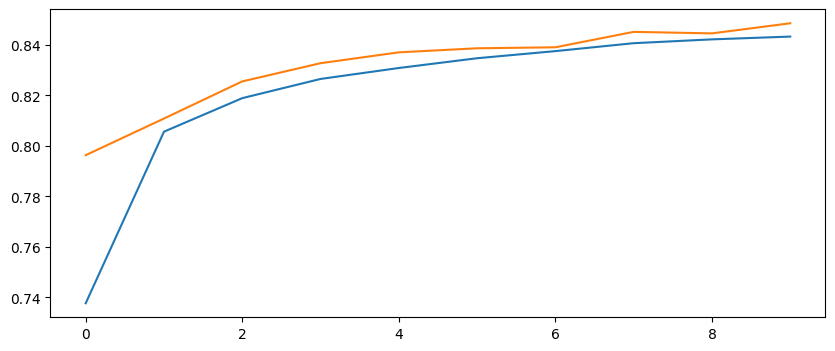

In [34]:
plt.figure(figsize=(10,4))
plt.plot(hist_per.history['accuracy'],label="Accurcay")
plt.plot(hist_per.history['val_accuracy'],label="Validation Accuracy")

# ANN 

In [51]:
# Conversion of 2d(Image) to 1d(Vector) for the ANN
X_train_ann = X_train.reshape(-1, 784)
X_test_ann = X_test.reshape(-1, 784)

In [54]:
ann = Sequential([
    Flatten(input_shape=(784,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

In [57]:
ann.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

### Training Phase

In [58]:
hist_ann = ann.fit(X_train_ann, y_train_cat,
                   validation_data=(X_test_ann, y_test_cat),
                                    batch_size=32,epochs=10,verbose=1)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8239 - loss: 0.4938 - val_accuracy: 0.8511 - val_loss: 0.4001
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8652 - loss: 0.3719 - val_accuracy: 0.8589 - val_loss: 0.3901
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8746 - loss: 0.3395 - val_accuracy: 0.8755 - val_loss: 0.3364
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8849 - loss: 0.3131 - val_accuracy: 0.8786 - val_loss: 0.3308
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8902 - loss: 0.2965 - val_accuracy: 0.8867 - val_loss: 0.3041
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8954 - loss: 0.2834 - val_accuracy: 0.8827 - val_loss: 0.3160
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8986 - loss: 0.2713 - val_accuracy: 0.8855 - val_loss: 0.3117
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9029 - loss: 0.2591 -

In [60]:
acc_ann = ann.evaluate(X_test_ann, y_test_cat, verbose=0)[1] #here the [1] -accurcay
acc_ann

0.8912000060081482

# CNN 

In [64]:
#reshape 
X_train_cnn = X_train.reshape(-1,28,28,1)
X_test_cnn = X_test.reshape(-1,28,28,1)

In [65]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

In [66]:
cnn.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

### Training Phase

In [69]:
hist_cnn = cnn.fit(X_train_cnn, y_train_cat,
                   validation_data=(X_test_cnn,y_test_cat),
                   batch_size=32,epochs=5,verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9269 - loss: 0.1906 - val_accuracy: 0.9141 - val_loss: 0.2405
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9329 - loss: 0.1775 - val_accuracy: 0.9202 - val_loss: 0.2331
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9348 - loss: 0.1698 - val_accuracy: 0.9206 - val_loss: 0.2366
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9376 - loss: 0.1667 - val_accuracy: 0.9155 - val_loss: 0.2551
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9397 - loss: 0.1593 - val_accuracy: 0.9194 - val_loss: 0.2443


In [71]:
acc_cnn = cnn.evaluate(X_test_cnn,y_test_cat,verbose=0)[1]
acc_cnn

0.9193999767303467

### Visualization

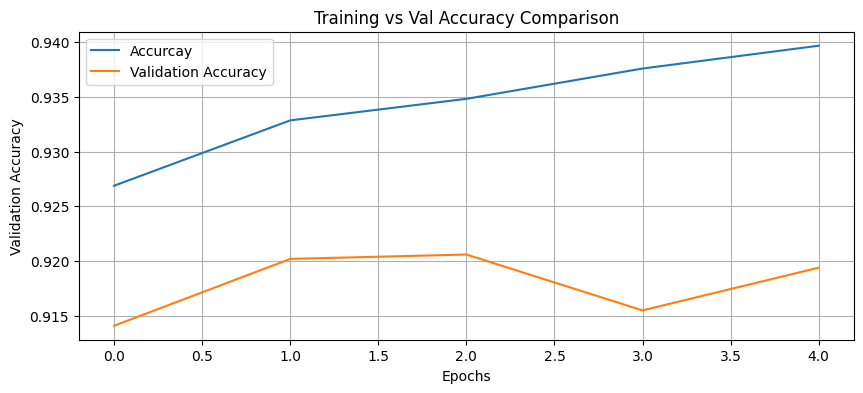

In [82]:
plt.figure(figsize=(10,4))
plt.plot(hist_cnn.history['accuracy'],label="Accurcay")
plt.plot(hist_cnn.history['val_accuracy'],label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Training vs Val Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.show()